# Lab: Linear Regression

**BINF 6210/8210 - Machine Learning for Bioinformatics**
___

**Topics covered:**
- Simple linear regression
- Multiple linear regression
- Training vs. testing performance
- Residual analysis
- Major assumptions of linear regression
- Multicollinearity
- Correlation matrices and Variance Inflation Factor (VIF)
- Interpretation of coefficients and model performance

## 1. Learning objectives

By the end of this notebook, students should be able to:

1. Fit a simple linear regression model with `sklearn.linear_model.LinearRegression`.
2. Fit a multiple linear regression model using several predictors.
3. Explain the difference between training performance and testing performance.
4. Calculate and interpret:
   - Mean Squared Error (MSE)
   - Root Mean Squared Error (RMSE)
   - Mean Absolute Error (MAE)
   - \(R^2\)
5. Use residual plots to assess whether a linear model is reasonable.
6. Describe the main assumptions of linear regression.
7. Identify multicollinearity using predictor correlations and Variance Inflation Factors (VIFs).
8. Explain why strong training performance does not necessarily imply strong generalization.

## 2. The linear regression model

### Simple linear regression

With one predictor \(x\), the model is

$$
y_i = \beta_0 + \beta_1 x_i + \epsilon_i
$$

where:

- \($y_i$\) is the response for observation \(i\),
- \($x_i$\) is the predictor,
- \($\beta_0$\) is the intercept,
- \($\beta_1$\) is the slope,
- \($\epsilon_i$\) is the error term.

The fitted model is

$$
\hat y_i = b_0 + b_1 x_i
$$

### Multiple linear regression

With \(p\) predictors,

$$
y_i =
\beta_0 +
\beta_1 x_{i1} +
\beta_2 x_{i2} +
\cdots +
\beta_p x_{ip} +
\epsilon_i
$$

or, in matrix notation,

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}.
$$

`LinearRegression` estimates the coefficients by ordinary least squares, minimizing

$$
\sum_{i=1}^{n}(y_i-\hat y_i)^2.
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# statsmodels is used only for VIF calculation.
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.precision", 3)

## 3. Load the California Housing dataset

The response variable is the median house value for a California census block group.

The predictors are:

- `MedInc`: median income
- `HouseAge`: median house age
- `AveRooms`: average rooms per household
- `AveBedrms`: average bedrooms per household
- `Population`: population
- `AveOccup`: average household occupancy
- `Latitude`
- `Longitude`

The response `MedHouseVal` is expressed in units of \$100,000.

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.325,41.0,6.984,1.024,322.0,2.556,37.88,-122.23,4.526
1,8.301,21.0,6.238,0.972,2401.0,2.110,37.86,-122.22,3.585
2,7.257,52.0,8.288,1.073,496.0,2.802,37.85,-122.24,3.521
3,5.643,52.0,5.817,1.073,558.0,2.548,37.85,-122.25,3.413
4,3.846,52.0,6.282,1.081,565.0,2.181,37.85,-122.25,3.422


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.0,2.069,1.154,0.150,1.196,1.797,2.647,5.000


## 4. Explore the variables

Before fitting a regression model, inspect the data.

Questions to consider:

- Are the predictors on very different scales?
- Are any variables strongly skewed?
- Are there extreme values?
- Does the response appear approximately continuous?

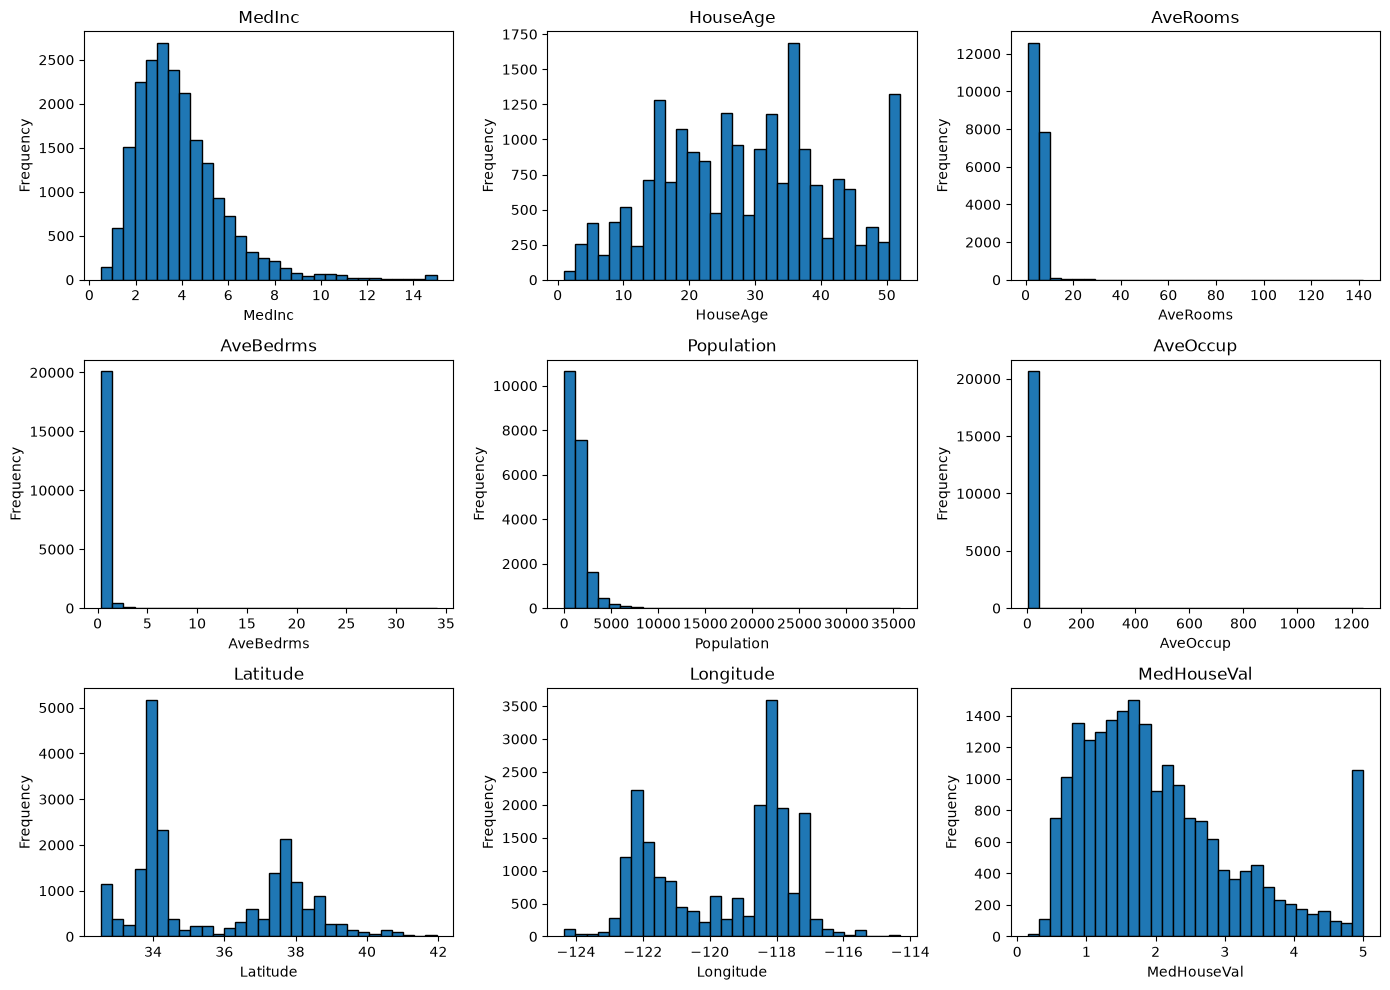

In [4]:
features_to_plot = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude",
    "MedHouseVal"
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, features_to_plot):
    ax.hist(df[col], bins=30, edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 5. Simple linear regression

We begin with only one predictor:

$$
\text{MedHouseVal} =
\beta_0 + \beta_1\text{MedInc} + \epsilon
$$

`MedInc` is chosen because median income has a clear relationship with housing value.

In [5]:
X_simple = df[["MedInc"]]
y = df["MedHouseVal"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train_s))
print("Testing observations:", len(X_test_s))

Training observations: 16512
Testing observations: 4128


### Why split the data?

The model coefficients are estimated from the **training set**.

The **testing set** contains observations that were not used to estimate the model. It provides a more realistic estimate of how the model may perform on future, unseen data.

A model can fit its training data very well yet perform poorly on new observations. This is called **overfitting**.

In [6]:
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

print("Intercept:", simple_model.intercept_)
print("Coefficient for MedInc:", simple_model.coef_[0])

Intercept: 0.44459729169078677
Coefficient for MedInc: 0.4193384939381274


The fitted equation has the form

$$
\widehat{\text{MedHouseVal}}
=
b_0 + b_1(\text{MedInc})
$$

The slope \($b_1$\) represents the expected change in predicted median house value for a one-unit increase in median income.

In [7]:
simple_equation = (
    f"Predicted MedHouseVal = {simple_model.intercept_:.3f} "
    f"+ {simple_model.coef_[0]:.3f} × MedInc"
)

print(simple_equation)

Predicted MedHouseVal = 0.445 + 0.419 × MedInc


### Visualize the simple regression line

/Users/xdu4/Documents/Duxiuxia/source_code_repository/du-lab-data-science/teach-machine-learning/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


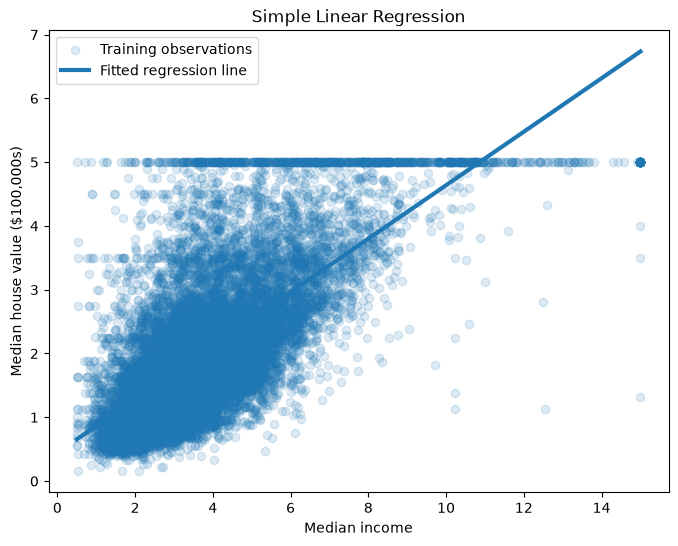

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_s["MedInc"],
    y_train_s,
    alpha=0.15,
    label="Training observations"
)

x_line = np.linspace(
    X_train_s["MedInc"].min(),
    X_train_s["MedInc"].max(),
    200
).reshape(-1, 1)

y_line = simple_model.predict(x_line)

plt.plot(x_line, y_line, linewidth=3, label="Fitted regression line")

plt.xlabel("Median income")
plt.ylabel("Median house value ($100,000s)")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

## 6. Evaluate training and testing performance

Several metrics are commonly used.

### Mean Absolute Error

$$
MAE =
\frac{1}{n}
\sum_{i=1}^n |y_i-\hat y_i|
$$

### Mean Squared Error

$$
MSE =
\frac{1}{n}
\sum_{i=1}^n (y_i-\hat y_i)^2
$$

### Root Mean Squared Error

$$
RMSE = \sqrt{MSE}
$$

RMSE is expressed in the same units as the response.

### Coefficient of determination

$$
R^2 =
1-
\frac{\sum_i(y_i-\hat y_i)^2}
{\sum_i(y_i-\bar y)^2}
$$

For an ordinary regression model with an intercept, \($R^2$\) measures the fraction of response variance explained by the fitted model.

In [9]:
def regression_metrics(model, X, y_true):
    y_pred = model.predict(X)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


simple_train_metrics = regression_metrics(
    simple_model, X_train_s, y_train_s
)

simple_test_metrics = regression_metrics(
    simple_model, X_test_s, y_test_s
)

simple_performance = pd.DataFrame(
    [simple_train_metrics, simple_test_metrics],
    index=["Training", "Testing"]
)

simple_performance

,MAE,MSE,RMSE,R2
Training,0.625,0.699,0.836,0.477
Testing,0.630,0.709,0.842,0.459


### Interpretation

Training performance is expected to be at least as good as testing performance because the model coefficients were estimated using the training observations.

However, a small difference between training and testing performance is usually not concerning.

A **large gap** can indicate overfitting, although for ordinary linear regression the size of the gap also depends on:

- sample size,
- number of predictors,
- noise,
- influential observations,
- whether the true relationship is actually linear.

## 7. Predicted versus observed values

A useful diagnostic plot compares observed responses with model predictions.

For a well-performing model, points should cluster around the diagonal line

$$
y = \hat y.
$$

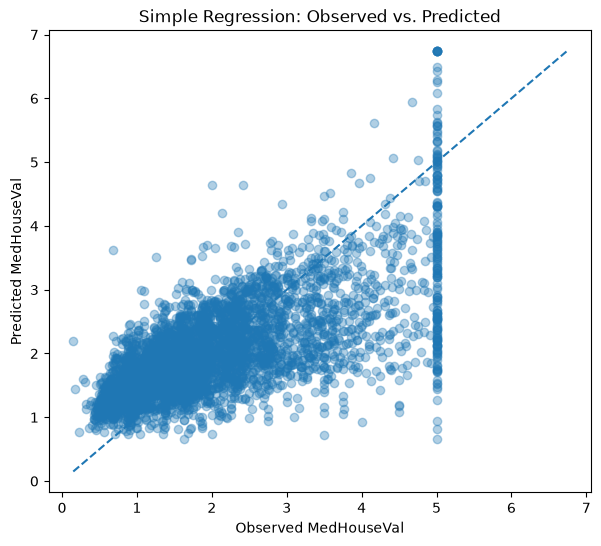

In [10]:
y_pred_test_s = simple_model.predict(X_test_s)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_s, y_pred_test_s, alpha=0.35)

limits = [
    min(y_test_s.min(), y_pred_test_s.min()),
    max(y_test_s.max(), y_pred_test_s.max())
]

plt.plot(limits, limits, linestyle="--")

plt.xlabel("Observed MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Simple Regression: Observed vs. Predicted")
plt.show()

## 8. Residuals

The residual for observation \(i\) is

$$
e_i = y_i-\hat y_i.
$$

Residuals are estimates of the unobserved errors \(\epsilon_i\).

Residual plots are therefore central to diagnosing whether the assumptions behind the regression model are plausible.

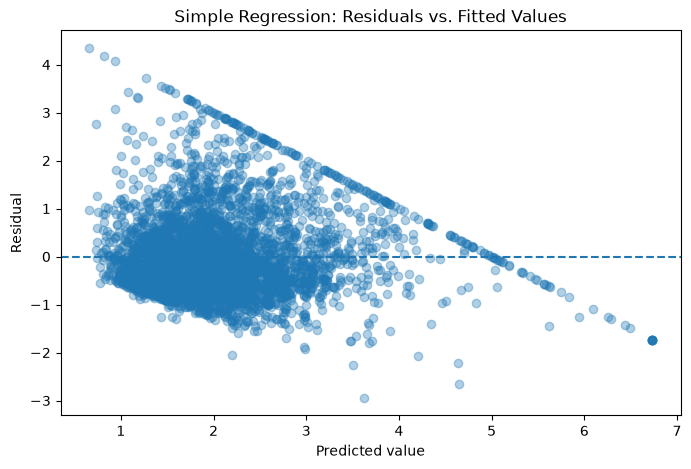

In [11]:
simple_residuals = y_test_s - y_pred_test_s

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test_s, simple_residuals, alpha=0.35)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted value")
plt.ylabel("Residual")
plt.title("Simple Regression: Residuals vs. Fitted Values")
plt.show()

### What would we like to see?

Ideally, residuals should form a roughly random horizontal cloud around zero.

Patterns can indicate problems:

- **Curved pattern:** the relationship may not be linear.
- **Funnel shape:** variance may not be constant.
- **Clusters:** an omitted categorical or group variable may be important.
- **Extreme points:** possible outliers or influential observations.

# Part II: Multiple Linear Regression

## 9. Fit a multiple linear regression model

Now use all eight predictors.

The model becomes

\[
\text{MedHouseVal}
=
\beta_0
+
\beta_1\text{MedInc}
+
\cdots
+
\beta_8\text{Longitude}
+
\epsilon.
\]

Each coefficient should be interpreted **while holding the other predictors constant**.

In [ ]:
X_multiple = df.drop(columns="MedHouseVal")

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple,
    y,
    test_size=0.20,
    random_state=42
)

multiple_model = LinearRegression()
multiple_model.fit(X_train_m, y_train_m)

In [ ]:
coef_table = pd.DataFrame({
    "Predictor": X_multiple.columns,
    "Coefficient": multiple_model.coef_
})

coef_table

### Important caution about coefficient magnitudes

Do **not** compare raw coefficient magnitudes directly to decide which variable is most important when predictors are measured on different scales.

For example:

- latitude is measured in degrees,
- population is measured in people,
- median income uses another scale entirely.

Standardization can make coefficient magnitudes more comparable, but standardized coefficients still do not automatically establish causal importance.

## 10. Training versus testing performance for multiple regression

In [ ]:
multiple_train_metrics = regression_metrics(
    multiple_model, X_train_m, y_train_m
)

multiple_test_metrics = regression_metrics(
    multiple_model, X_test_m, y_test_m
)

multiple_performance = pd.DataFrame(
    [multiple_train_metrics, multiple_test_metrics],
    index=["Training", "Testing"]
)

multiple_performance

## 11. Compare simple and multiple regression

Adding useful predictors should generally improve training performance because the multiple regression model has greater flexibility.

The more important question is whether **testing performance** improves.

In [ ]:
comparison = pd.DataFrame({
    "Simple Train": simple_train_metrics,
    "Simple Test": simple_test_metrics,
    "Multiple Train": multiple_train_metrics,
    "Multiple Test": multiple_test_metrics
}).T

comparison

### Questions

1. Which model has the larger training \(R^2\)?
2. Which model has the larger testing \(R^2\)?
3. Which model has the lower test RMSE?
4. Is the difference between training and testing performance large?
5. Does adding predictors appear to improve generalization?

## 12. Residual diagnostics for the multiple regression model

In [ ]:
y_pred_train_m = multiple_model.predict(X_train_m)
y_pred_test_m = multiple_model.predict(X_test_m)

residuals_train_m = y_train_m - y_pred_train_m
residuals_test_m = y_test_m - y_pred_test_m

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test_m, residuals_test_m, alpha=0.35)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted value")
plt.ylabel("Residual")
plt.title("Multiple Regression: Residuals vs. Fitted Values")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(residuals_test_m, bins=40, edgecolor="black")

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Test Residuals")
plt.show()

## 13. Major assumptions of ordinary linear regression

The assumptions are often summarized imprecisely. It is useful to distinguish assumptions about the **conditional mean**, **errors**, and **predictors**.

### 1. Linearity

The expected response is a linear function of the predictors:

\[
E(Y\mid X)
=
\beta_0+\beta_1X_1+\cdots+\beta_pX_p.
\]

This does **not** require every raw predictor-response scatterplot to be a perfect straight line. It means the chosen model specification correctly represents the conditional mean.

Possible warning signs:

- curvature in residual plots,
- systematic residual patterns.

Potential remedies include transformations, interaction terms, or nonlinear models.

---

### 2. Independence of observations/errors

Errors should not be systematically correlated across observations.

This assumption is often violated in:

- repeated measurements,
- longitudinal studies,
- family data,
- spatial data,
- batch-structured experiments.

For example, samples from the same patient may be more similar than samples from different patients.

---

### 3. Constant variance (homoscedasticity)

The conditional error variance should be approximately constant:

\[
Var(\epsilon_i \mid X_i)=\sigma^2.
\]

A funnel-shaped residual plot can indicate heteroscedasticity.

---

### 4. Errors centered at zero

Under the standard model,

\[
E(\epsilon_i\mid X_i)=0.
\]

This is closely connected to having a correctly specified conditional mean.

---

### 5. Approximate normality of errors

For classical hypothesis tests and confidence intervals, one often assumes

\[
\epsilon_i \sim N(0,\sigma^2).
\]

Normality is **not required to calculate ordinary least-squares coefficients**.

With large samples, moderate deviations from normality may be much less important for coefficient estimation than violations such as nonlinearity or dependence.

---

### 6. No perfect multicollinearity

No predictor should be an exact linear combination of the others.

Strong but imperfect multicollinearity does not prevent fitting the model, but it can make coefficient estimates unstable.

## 14. Inspect residual normality with a Q-Q plot

A Q-Q plot compares residual quantiles with those expected under a normal distribution.

We will use `scipy.stats.probplot`.

In [ ]:
from scipy import stats

plt.figure(figsize=(7, 6))
stats.probplot(residuals_test_m, dist="norm", plot=plt)
plt.title("Q-Q Plot of Test Residuals")
plt.show()

### Interpreting a Q-Q plot

If residuals are approximately normal, points should roughly follow the reference line.

Departures at the ends indicate heavier or lighter tails than a normal distribution.

Remember that normality of residuals is primarily important for classical inferential procedures. It is **not** a requirement for generating predictions with `LinearRegression`.

# Part III: Multicollinearity

## 15. What is multicollinearity?

Multicollinearity occurs when predictors contain overlapping linear information.

Suppose two predictors satisfy approximately

\[
X_2 \approx a+bX_1.
\]

Then the regression model may have difficulty deciding how much of the response association should be assigned to \(X_1\) versus \(X_2\).

### Consequences

Strong multicollinearity can:

- inflate coefficient uncertainty,
- make coefficients unstable,
- produce unexpected coefficient signs,
- make individual coefficient interpretation difficult.

Importantly, a model can still have good predictive performance even when individual coefficients are unstable.

## 16. Pairwise predictor correlations

A correlation matrix is a useful first check.

However, it detects only **pairwise** relationships. Multicollinearity can involve combinations of three or more predictors, so correlation alone is not sufficient.

In [ ]:
corr = X_train_m.corr()

corr

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr, aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

fig.colorbar(im, ax=ax, label="Pearson correlation")

plt.title("Predictor Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Find the strongest absolute predictor correlations,
# excluding correlations of a variable with itself.

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=lambda x: x.abs(), ascending=False)
)

corr_pairs.head(10)

### Discussion

A large absolute correlation, for example

\[
|r| > 0.8,
\]

is often treated as a warning sign, but there is no universal cutoff.

Also remember:

> Low pairwise correlations do not guarantee the absence of multicollinearity.

## 17. Variance Inflation Factor (VIF)

For predictor \(X_j\), regress it on the other predictors and calculate \(R_j^2\).

Then

\[
VIF_j = \frac{1}{1-R_j^2}.
\]

Interpretation:

- \(VIF=1\): no linear redundancy with the other predictors.
- Larger VIF: more predictor variance is explained by the other predictors.

Rules such as VIF > 5 or VIF > 10 are common heuristics, not strict laws.

In [ ]:
X_vif = X_train_m.copy()

vif_table = pd.DataFrame({
    "Predictor": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table.sort_values("VIF", ascending=False)

### Why does multicollinearity matter less for some prediction tasks?

Suppose two predictors carry nearly the same information.

The model may estimate very different individual coefficients across different training samples, but the **combined prediction**

\[
b_1X_1+b_2X_2
\]

may remain relatively stable.

Thus:

- **prediction** can remain good,
- **coefficient interpretation** can become unreliable.

This distinction is especially important in high-dimensional biological datasets, where correlated molecular features are common.

## 18. Create an intentionally collinear predictor

To make the effect easier to see, create an artificial variable that is almost a duplicate of `MedInc`.

In [ ]:
rng = np.random.default_rng(42)

X_collinear = X_train_m.copy()

X_collinear["MedInc_duplicate"] = (
    X_collinear["MedInc"]
    + rng.normal(0, 0.05, size=len(X_collinear))
)

X_collinear[["MedInc", "MedInc_duplicate"]].corr()

In [ ]:
vif_collinear = pd.DataFrame({
    "Predictor": X_collinear.columns,
    "VIF": [
        variance_inflation_factor(X_collinear.values, i)
        for i in range(X_collinear.shape[1])
    ]
})

vif_collinear.sort_values("VIF", ascending=False)

We would expect the VIFs for `MedInc` and `MedInc_duplicate` to become very large because the two variables contain nearly the same information.

## 19. Compare coefficients with and without the duplicate predictor

In [ ]:
model_original = LinearRegression()
model_original.fit(X_train_m, y_train_m)

model_collinear = LinearRegression()
model_collinear.fit(X_collinear, y_train_m)

coef_original = pd.Series(
    model_original.coef_,
    index=X_train_m.columns,
    name="Original model"
)

coef_collinear = pd.Series(
    model_collinear.coef_,
    index=X_collinear.columns,
    name="Collinear model"
)

pd.concat([coef_original, coef_collinear], axis=1)

Notice that the income-related effect is now distributed between two highly correlated variables.

This illustrates an important principle:

> High multicollinearity makes individual coefficients difficult to interpret, even when overall prediction remains reasonable.

## 20. Training and testing performance after introducing multicollinearity

To evaluate the collinear model on the test set, construct the duplicate variable using the **same mechanism**: `MedInc` plus a small amount of random noise.

The exact noise values differ between training and testing observations, just as measurement noise would differ across samples.

In [ ]:
rng_test = np.random.default_rng(123)

X_test_collinear = X_test_m.copy()
X_test_collinear["MedInc_duplicate"] = (
    X_test_collinear["MedInc"]
    + rng_test.normal(0, 0.05, size=len(X_test_collinear))
)

collinear_train_metrics = regression_metrics(
    model_collinear,
    X_collinear,
    y_train_m
)

collinear_test_metrics = regression_metrics(
    model_collinear,
    X_test_collinear,
    y_test_m
)

pd.DataFrame(
    [multiple_train_metrics, multiple_test_metrics,
     collinear_train_metrics, collinear_test_metrics],
    index=[
        "Original multiple: training",
        "Original multiple: testing",
        "Collinear multiple: training",
        "Collinear multiple: testing"
    ]
)

## 21. A compact regression workflow

A practical workflow is:

1. Define the response and predictors.
2. Perform exploratory data analysis.
3. Split data into training and testing sets.
4. Fit the regression model using the training set.
5. Inspect coefficients, but interpret them in context.
6. Evaluate training performance.
7. Evaluate testing performance.
8. Compare training and testing results.
9. Inspect residuals.
10. Investigate linearity and constant variance.
11. Consider dependence introduced by study design.
12. Examine predictor correlations and VIF.
13. Revise the model if assumptions are seriously violated.

## 22. Important distinction: assumptions for estimation, inference, and prediction

Students often encounter statements such as:

> "Linear regression requires normally distributed data."

That statement is incorrect.

The **predictors and response themselves do not need to be normally distributed**.

The traditional normality assumption concerns the **errors conditional on the predictors**:

\[
\epsilon \mid X \sim N(0,\sigma^2).
\]

Furthermore:

- Ordinary least-squares coefficients can be calculated without normal errors.
- Normal-error assumptions are most important for classical small-sample inference.
- Prediction quality depends more directly on whether the fitted relationship generalizes to new data.

## 23. Optional exercise: use fewer predictors

Fit a model using only:

- `MedInc`
- `HouseAge`
- `AveRooms`

Then answer:

1. What is the training \(R^2\)?
2. What is the testing \(R^2\)?
3. How does test RMSE compare with the full model?
4. Does removing predictors substantially reduce predictive performance?
5. Is the simpler model easier to interpret?

In [ ]:
selected_predictors = ["MedInc", "HouseAge", "AveRooms"]

X_small = df[selected_predictors]

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_small,
    y,
    test_size=0.20,
    random_state=42
)

small_model = LinearRegression()
small_model.fit(X_train_small, y_train_small)

pd.DataFrame(
    [
        regression_metrics(small_model, X_train_small, y_train_small),
        regression_metrics(small_model, X_test_small, y_test_small)
    ],
    index=["Training", "Testing"]
)

## 24. Optional exercise: investigate a possible nonlinear relationship

Choose one predictor and inspect its scatterplot against `MedHouseVal`.

Questions:

1. Does the relationship appear linear?
2. Would a transformation help?
3. Would a polynomial term make biological or scientific sense?
4. How could you test whether adding such a term improves **test-set** performance rather than merely training performance?

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["AveRooms"], df["MedHouseVal"], alpha=0.15)

plt.xlabel("Average rooms")
plt.ylabel("Median house value")
plt.title("Explore Possible Nonlinearity")
plt.show()

## 25. Summary

### Simple linear regression
Uses one predictor:

\[
\hat y = b_0+b_1x.
\]

### Multiple linear regression
Uses several predictors:

\[
\hat y = b_0+b_1x_1+\cdots+b_px_p.
\]

### Training vs. testing
Training performance describes fit to data used to estimate the model. Testing performance is more informative about generalization to unseen observations.

### Residuals
Residuals help assess:

- linearity,
- constant variance,
- unusual observations,
- approximate error distribution.

### Multicollinearity
Highly related predictors can make coefficients unstable. Examine:

- correlation matrices,
- VIF,
- scientific redundancy among predictors.

### Core assumptions
Key assumptions include:

- a correctly specified linear conditional mean,
- independence,
- constant error variance,
- errors centered around zero,
- no perfect multicollinearity,
- approximate error normality when classical inference requires it.

In machine learning, always distinguish **good fit to the training data** from **good predictive performance on unseen data**.

# Discussion questions

1. Why can training \(R^2\) increase when predictors are added even if the predictors are not truly useful?
2. Why is test-set performance more relevant for prediction?
3. Can a regression model have high \(R^2\) but still violate important assumptions?
4. Why can multicollinearity harm interpretation more than prediction?
5. Does linear regression require the response variable to be normally distributed?
6. What kinds of bioinformatics studies are especially likely to violate independence?
7. If residual variance increases with fitted value, what assumption may be violated?
8. Why should preprocessing operations that learn from data be fit using the training set rather than the entire dataset?